# Week2 Quiz1：貓狗影像二元分類 + Threshold 調校

流程：特徵工程 → 7:2:1 切分 → StandardScaler → Stratified 5-Fold CV → 訓練 → 門檻調校 → Test 評估

## 1. 環境設定與模組載入

In [2]:
import os
import sys
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import shutil
import kagglehub

In [ ]:
# 1. 下載資料集到本地快取
cache_path = kagglehub.dataset_download("ziluntsengalan/catdogs")
print("Kaggle 快取路徑:", cache_path)

# 2. 定義目標資料夾路徑
target_dir = "data"
os.makedirs(target_dir, exist_ok=True)

# 3. 將快取內的資料夾與檔案同步至 data/
for item in os.listdir(cache_path):
    src = os.path.join(cache_path, item)
    dst = os.path.join(target_dir, item)
    if os.path.isdir(src):
        # dirs_exist_ok=True 確保目標資料夾存在時也能覆蓋/更新內容
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("同步完成！目前 data 資料夾內容:", os.listdir(target_dir))
# 讓 notebook 不論從哪個目錄啟動，都找得到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import Code.quiz1 as q1
reload(q1)

RANDOM_STATE = 42                 # 固定亂數種子，確保結果可重現
DATA_DIR = os.path.join(BASE_DIR, 'data', 'Datasets')
print('資料路徑:', DATA_DIR, '| 存在:', os.path.isdir(DATA_DIR))

100%|██████████| 788M/788M [01:31<00:00, 9.05MB/s] 

Extracting model files...


Kaggle 快取路徑: C:\Users\Alan\.cache\kagglehub\datasets\ziluntsengalan\catdogs\versions\1
同步完成！目前 data 資料夾內容: ['Datasets']
資料路徑: c:\Users\Alan\python\MMIP\week2\data\Datasets | 存在: True


## 2. 特徵工程：讀圖並建立 X / y

In [36]:
# MAX_PER_CLASS：每類最多取幾張（原始資料每類 12500 張，先抽樣加快實驗）
# 想跑完整資料集就設成 None
MAX_PER_CLASS = 12500

X, y, paths = q1.build_dataset(
    DATA_DIR,
    max_per_class=MAX_PER_CLASS,
    resize=(128, 128),
    seed=RANDOM_STATE,
)
print('特徵維度:', X.shape[1], '| 特徵名稱:', q1.FEATURE_NAMES)
print('類別分布 (0=cat, 1=dog):', np.bincount(y))

  [cat] 已處理 500/12500 張
  [cat] 已處理 1000/12500 張
  [cat] 已處理 1500/12500 張
  [cat] 已處理 2000/12500 張
  [cat] 已處理 2500/12500 張
  [cat] 已處理 3000/12500 張
  [cat] 已處理 3500/12500 張
  [cat] 已處理 4000/12500 張
  [cat] 已處理 4500/12500 張
  [cat] 已處理 5000/12500 張
  [cat] 已處理 5500/12500 張
  [cat] 已處理 6000/12500 張
  [cat] 已處理 6500/12500 張
  [cat] 已處理 7000/12500 張
  [cat] 已處理 7500/12500 張
  [cat] 已處理 8000/12500 張
  [cat] 已處理 8500/12500 張
  [cat] 已處理 9000/12500 張
  [cat] 已處理 9500/12500 張
  [cat] 已處理 10000/12500 張
  [cat] 已處理 10500/12500 張
  [cat] 已處理 11000/12500 張
  [cat] 已處理 11500/12500 張
  [cat] 已處理 12000/12500 張
  [cat] 已處理 12500/12500 張
[cat] 完成，標籤=0，有效樣本數=12498
  [dog] 已處理 500/12500 張
  [dog] 已處理 1000/12500 張
  [dog] 已處理 1500/12500 張
  [dog] 已處理 2000/12500 張
  [dog] 已處理 2500/12500 張
  [dog] 已處理 3000/12500 張
  [dog] 已處理 3500/12500 張
  [dog] 已處理 4000/12500 張
  [dog] 已處理 4500/12500 張
  [dog] 已處理 5000/12500 張
  [dog] 已處理 5500/12500 張
  [dog] 已處理 6000/12500 張
  [dog] 已處理 6500/12500 張
  [dog] 已處理 7000/125

In [37]:
# 檢視特徵分布，確認數值合理、沒有 NaN
df = q1.to_dataframe(X, y)
display(df.head())
display(df.describe().T[['mean', 'std', 'min', 'max']])
print('NaN 總數:', int(df.isna().sum().sum()))

,R_mean,G_mean,B_mean,R_std,G_std,B_std,H_mean,S_mean,V_mean,H_std,S_std,V_std,gray_mean,gray_std,width,height,aspect_ratio,edge_density,label
0,167.801941,130.023315,61.817871,78.527008,71.413391,57.304550,20.050354,180.804016,167.818787,3.196471,54.531906,78.503998,133.544556,70.880066,500.0,375.0,1.333333,0.057007,0
1,78.845520,68.344482,68.044312,38.970055,32.345840,32.581413,56.077515,60.845032,83.096680,62.519009,23.431541,37.953308,71.458313,33.836205,300.0,281.0,1.067616,0.145874,0
2,117.582153,111.873718,96.932373,55.632736,59.806973,51.409718,54.801086,74.484619,123.012512,55.489212,51.288692,56.299393,111.879761,56.570015,489.0,500.0,0.978000,0.179749,0
3,188.076721,158.980835,148.012939,43.715225,62.659454,67.549011,29.264221,65.032227,188.863770,40.796577,57.248760,44.410702,166.437500,56.274178,403.0,500.0,0.806000,0.129028,0
4,111.910339,105.408203,91.911865,65.886147,70.593208,75.304771,47.358704,78.678284,115.431763,44.047379,55.650429,69.574425,105.808044,69.272659,150.0,150.0,1.000000,0.220581,0


,mean,std,min,max
R_mean,124.498077,29.646902,12.226562,255.000000
G_mean,116.072960,28.259514,15.556763,255.000000
B_mean,106.320580,29.496662,2.963196,255.000000
R_std,57.228222,14.064998,0.000000,116.146088
G_std,56.039516,13.782771,0.000000,113.467865
B_std,56.108887,14.145656,0.000000,114.890701
H_mean,52.213459,25.944782,0.000000,167.692566
S_mean,64.607506,31.222319,0.000000,241.440247
V_mean,130.539673,29.028156,23.394653,255.000000
H_std,42.212860,17.434795,0.000000,86.721634


NaN 總數: 0


## 3. 資料切分（7:2:1，stratify 固定）

In [38]:
# 先切出 10% Test，再從剩下的 90% 切出 20/90 當 Validation，得到 70:20:10
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20 / 0.90, stratify=y_temp, random_state=RANDOM_STATE)

total = len(y)
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'{name:<5s}: {len(yy):5d} 筆 ({len(yy)/total:.1%}) | 類別分布={np.bincount(yy)}')

Train: 17497 筆 (70.0%) | 類別分布=[8748 8749]
Val  :  5000 筆 (20.0%) | 類別分布=[2500 2500]
Test :  2500 筆 (10.0%) | 類別分布=[1250 1250]


## 4. 特徵縮放（只在 70% 訓練集 fit，避免資料外洩）

In [39]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 只用訓練集學習 mean/std
X_val_s = scaler.transform(X_val)           # 驗證集、測試集僅套用，不重新 fit
X_test_s = scaler.transform(X_test)

print('訓練集縮放後 mean≈0, std≈1:',
      np.round(X_train_s.mean(), 6), np.round(X_train_s.std(), 6))
print('驗證集縮放後 mean/std:',
      np.round(X_val_s.mean(), 4), np.round(X_val_s.std(), 4))

訓練集縮放後 mean≈0, std≈1: 0.0 1.0
驗證集縮放後 mean/std: 0.0193 1.0042


## 5. Stratified 5-Fold 交叉驗證（僅在訓練集上）

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

cv_rows = []
for name, clf in candidates.items():
    acc = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='f1')
    auc_ = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='roc_auc')
    cv_rows.append({'model': name,
                    'acc_mean': acc.mean(), 'acc_std': acc.std(),
                    'f1_mean': f1.mean(), 'f1_std': f1.std(),
                    'auc_mean': auc_.mean(), 'auc_std': auc_.std()})
    print(f'{name:<20s} Acc={acc.mean():.4f}±{acc.std():.4f} | '
          f'F1={f1.mean():.4f}±{f1.std():.4f} | AUC={auc_.mean():.4f}±{auc_.std():.4f}')

cv_df = pd.DataFrame(cv_rows).set_index('model')
display(cv_df)

LogisticRegression   Acc=0.6208±0.0113 | F1=0.6073±0.0119 | AUC=0.6688±0.0143
RandomForest         Acc=0.6371±0.0064 | F1=0.6319±0.0048 | AUC=0.6905±0.0093


,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
model,,,,,,
LogisticRegression,0.620848,0.011312,0.607255,0.011947,0.668760,0.014266
RandomForest,0.637137,0.006447,0.631894,0.004758,0.690493,0.009339


## 6. 模型訓練（選 CV 表現最佳者）

In [41]:
best_model_name = cv_df['f1_mean'].idxmax()   # 以 CV 平均 F1 挑選模型
model = candidates[best_model_name]
model.fit(X_train_s, y_train)
print('選用模型:', best_model_name)

# 取得正類 (dog=1) 的預測機率，之後才能調整門檻
val_probs = model.predict_proba(X_val_s)[:, 1]
print('驗證集機率範圍:', val_probs.min().round(4), '~', val_probs.max().round(4))

選用模型: RandomForest
驗證集機率範圍: 0.0667 ~ 0.98


## 7. Validation：預設門檻 0.5 vs. 微調後最佳門檻

In [42]:
# 7-1 預設門檻 0.5
m_default = q1.evaluate_threshold(y_val, val_probs, threshold=0.5, title='Validation / 預設門檻')

[Validation / 預設門檻] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat      1635       865
  true_dog       907      1593
  Accuracy : 0.6456
  Precision: 0.6481
  Recall   : 0.6372
  F1-Score : 0.6426



最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.3710 | best f1 = 0.6915
  該門檻下 Acc=0.6050, P=0.5673, R=0.8852



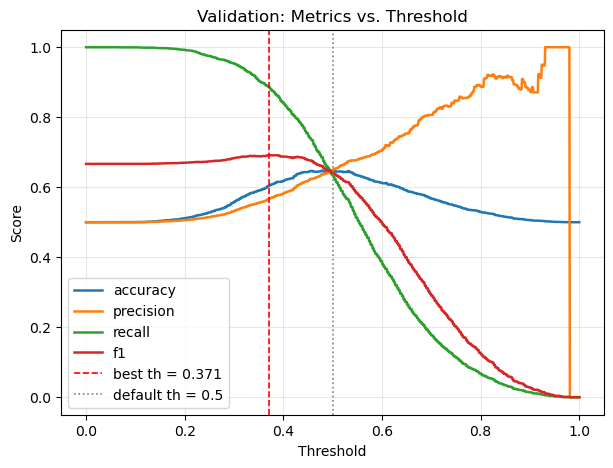

In [43]:
# 7-2 自動搜尋最佳門檻（目標：最大化 F1）
best_th, best_f1, th_table = q1.find_best_threshold(y_val, val_probs, n_steps=1001, metric='f1')
q1.plot_threshold_curves(th_table, best_th, title='Validation: Metrics vs. Threshold')

In [44]:
# 7-3 兩組門檻並排比較
compare_df = q1.compare_thresholds(y_val, val_probs, th_a=0.5, th_b=best_th,
                                   name_a='Default 0.5', name_b=f'Tuned {best_th:.3f}')
display(compare_df)
print('F1 提升:', f'{compare_df["f1"].iloc[1] - compare_df["f1"].iloc[0]:+.4f}')

[Default 0.5] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat      1635       865
  true_dog       907      1593
  Accuracy : 0.6456
  Precision: 0.6481
  Recall   : 0.6372
  F1-Score : 0.6426

[Tuned 0.371] Threshold = 0.3710
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat       812      1688
  true_dog       287      2213
  Accuracy : 0.6050
  Precision: 0.5673
  Recall   : 0.8852
  F1-Score : 0.6915



,threshold,accuracy,precision,recall,f1
Default 0.5,0.500,0.6456,0.648088,0.6372,0.642598
Tuned 0.371,0.371,0.6050,0.567290,0.8852,0.691454


F1 提升: +0.0489


## 8. Validation 視覺化：ROC / PR / 雙門檻混淆矩陣

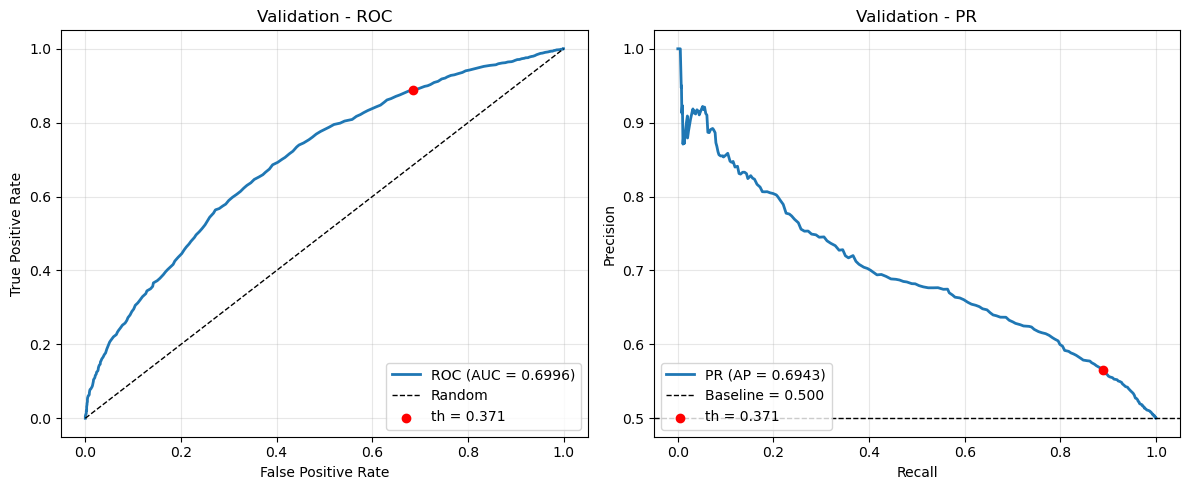

Validation ROC-AUC = 0.6996 | Average Precision = 0.6943


In [45]:
val_auc, val_ap = q1.plot_evaluation_curves(y_val, val_probs, best_th=best_th, suptitle='Validation')
print(f'Validation ROC-AUC = {val_auc:.4f} | Average Precision = {val_ap:.4f}')

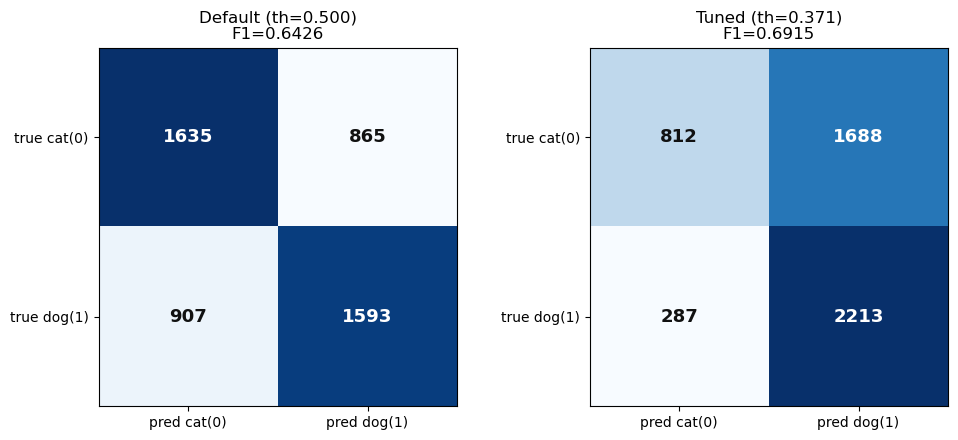

In [61]:
_ = q1.plot_dual_confusion_matrix(y_val, val_probs, th_a=0.5, th_b=best_th,
                                  name_a='Default', name_b='Tuned')

## 9. 最終測試：把最佳門檻套用到 10% Test 集

[Test / 預設門檻 0.5] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat       822       428
  true_dog       475       775
  Accuracy : 0.6388
  Precision: 0.6442
  Recall   : 0.6200
  F1-Score : 0.6319

[Test / 最佳門檻 0.371] Threshold = 0.3710
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat       393       857
  true_dog       157      1093
  Accuracy : 0.5944
  Precision: 0.5605
  Recall   : 0.8744
  F1-Score : 0.6831



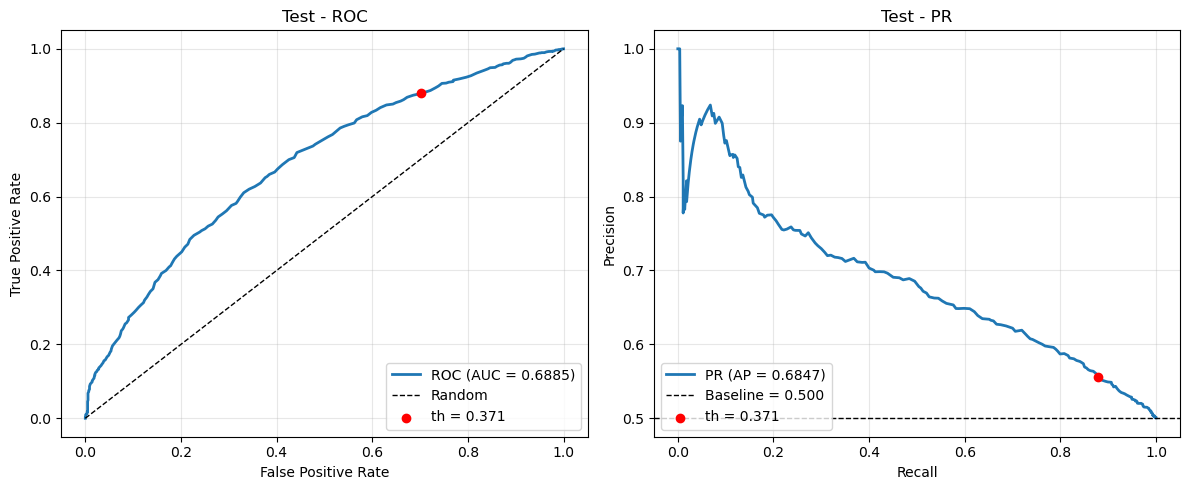

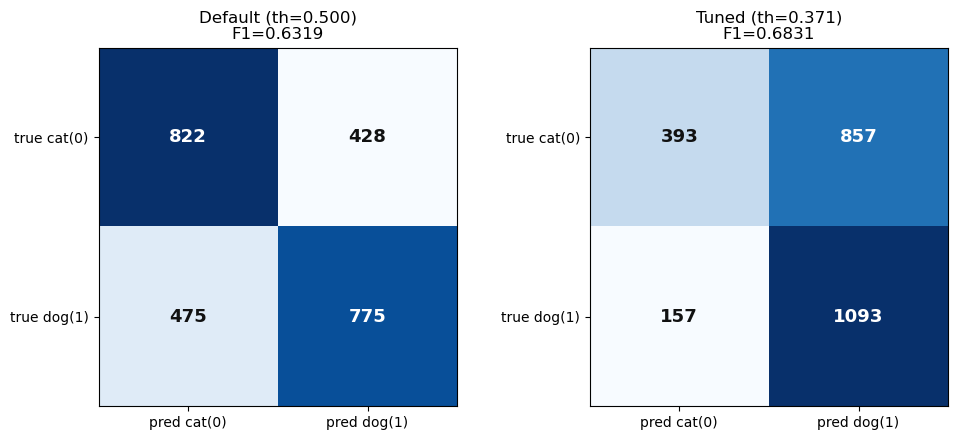

In [62]:
test_probs = model.predict_proba(X_test_s)[:, 1]

m_test_default = q1.evaluate_threshold(y_test, test_probs, 0.5, title='Test / 預設門檻 0.5')
m_test_tuned = q1.evaluate_threshold(y_test, test_probs, best_th, title=f'Test / 最佳門檻 {best_th:.3f}')

test_auc, test_ap = q1.plot_evaluation_curves(y_test, test_probs, best_th=best_th, suptitle='Test')
_ = q1.plot_dual_confusion_matrix(y_test, test_probs, 0.5, best_th,
                                  name_a='Default', name_b='Tuned')

## 10. 結果總表

In [48]:
summary = pd.DataFrame([
    {'dataset': 'Validation', 'threshold': 0.5, **{k: m_default[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'dataset': 'Validation', 'threshold': best_th, **{k: q1.evaluate_threshold(y_val, val_probs, best_th, verbose=False)[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'dataset': 'Test', 'threshold': 0.5, **{k: m_test_default[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'dataset': 'Test', 'threshold': best_th, **{k: m_test_tuned[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
])
display(summary.round(4))

print(f'模型: {best_model_name} | 最佳門檻: {best_th:.4f} (由 Validation 以 F1 最大化求得)')
print(f'Validation AUC={val_auc:.4f} / Test AUC={test_auc:.4f}')

,dataset,threshold,accuracy,precision,recall,f1
0,Validation,0.500,0.6456,0.6481,0.6372,0.6426
1,Validation,0.371,0.6050,0.5673,0.8852,0.6915
2,Test,0.500,0.6388,0.6442,0.6200,0.6319
3,Test,0.371,0.5944,0.5605,0.8744,0.6831


模型: RandomForest | 最佳門檻: 0.3710 (由 Validation 以 F1 最大化求得)
Validation AUC=0.6996 / Test AUC=0.6885


# 11. 換另一種演算法重新建模並比較

模型 A：第 6 節選用的模型；模型 B：`candidates` 中另一種演算法。兩者共用同一組 Scaler 與同一份 Validation Set。

## 11-1 訓練模型 B 並各自調校門檻

In [49]:
# 模型 B = candidates 中「不是模型 A」的那一個演算法
name_a = best_model_name
name_b = [n for n in candidates if n != name_a][0]

model_a = model                                   # 第 6 節已訓練完成
model_b = candidates[name_b]
model_b.fit(X_train_s, y_train)                   # 用完全相同的訓練集與縮放器
print('模型 A:', name_a, '| 模型 B:', name_b)

# 兩個模型在「同一份 Validation Set」上的正類機率
probs_a = model_a.predict_proba(X_val_s)[:, 1]
probs_b = model_b.predict_proba(X_val_s)[:, 1]

# 各自以 F1 最大化找出合適門檻（門檻不共用，每個模型的機率分布不同）
th_a, f1_a, tab_a = q1.find_best_threshold(y_val, probs_a, n_steps=1001, metric='f1')
th_b, f1_b, tab_b = q1.find_best_threshold(y_val, probs_b, n_steps=1001, metric='f1')
print(f'{name_a}: best_th={th_a:.4f} | {name_b}: best_th={th_b:.4f}')

模型 A: RandomForest | 模型 B: LogisticRegression
最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.3710 | best f1 = 0.6915
  該門檻下 Acc=0.6050, P=0.5673, R=0.8852

最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.3560 | best f1 = 0.6850
  該門檻下 Acc=0.5846, P=0.5517, R=0.9032

RandomForest: best_th=0.3710 | LogisticRegression: best_th=0.3560


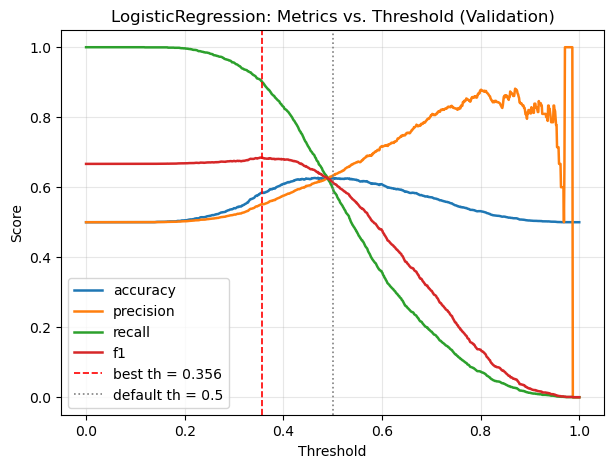

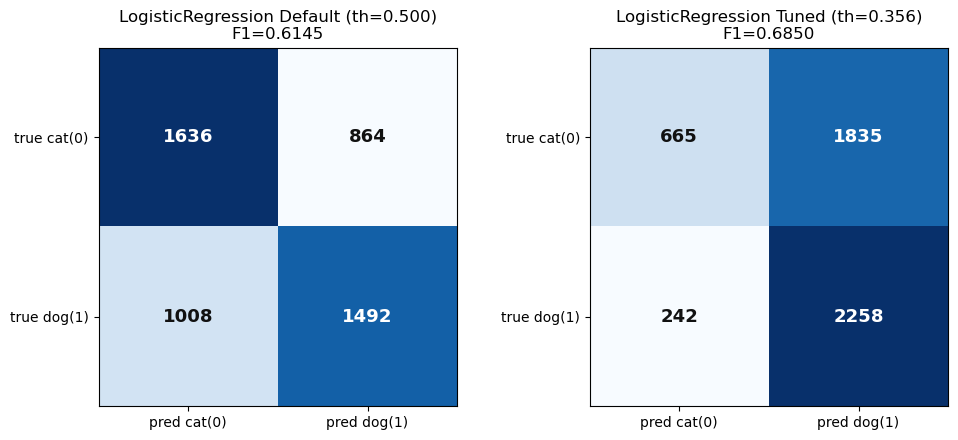

In [63]:
# 模型 B 的門檻掃描曲線與雙門檻混淆矩陣
q1.plot_threshold_curves(tab_b, th_b, title=f'{name_b}: Metrics vs. Threshold (Validation)')
_ = q1.plot_dual_confusion_matrix(y_val, probs_b, 0.5, th_b,
                                  name_a=f'{name_b} Default', name_b=f'{name_b} Tuned')

## 11-2 相同 Validation Set 上比較兩個模型

In [51]:
prob_dict = {name_a: probs_a, name_b: probs_b}

# (a) 預設門檻 0.5：純粹比較模型本身
print('=== 預設門檻 0.5 ===')
cmp_default = q1.compare_models(y_val, prob_dict, {name_a: 0.5, name_b: 0.5})

# (b) 各自調校後的最佳門檻
print('\n=== 各自 F1 最佳門檻 ===')
cmp_tuned = q1.compare_models(y_val, prob_dict, {name_a: th_a, name_b: th_b})

=== 預設門檻 0.5 ===
                    threshold  accuracy  precision  recall      f1  FP(cat誤判成dog)  FN(dog誤判成cat)
model                                                                                           
RandomForest              0.5    0.6456     0.6481  0.6372  0.6426            865            907
LogisticRegression        0.5    0.6256     0.6333  0.5968  0.6145            864           1008

=== 各自 F1 最佳門檻 ===
                    threshold  accuracy  precision  recall      f1  FP(cat誤判成dog)  FN(dog誤判成cat)
model                                                                                           
RandomForest            0.371    0.6050     0.5673  0.8852  0.6915           1688            287
LogisticRegression      0.356    0.5846     0.5517  0.9032  0.6850           1835            242


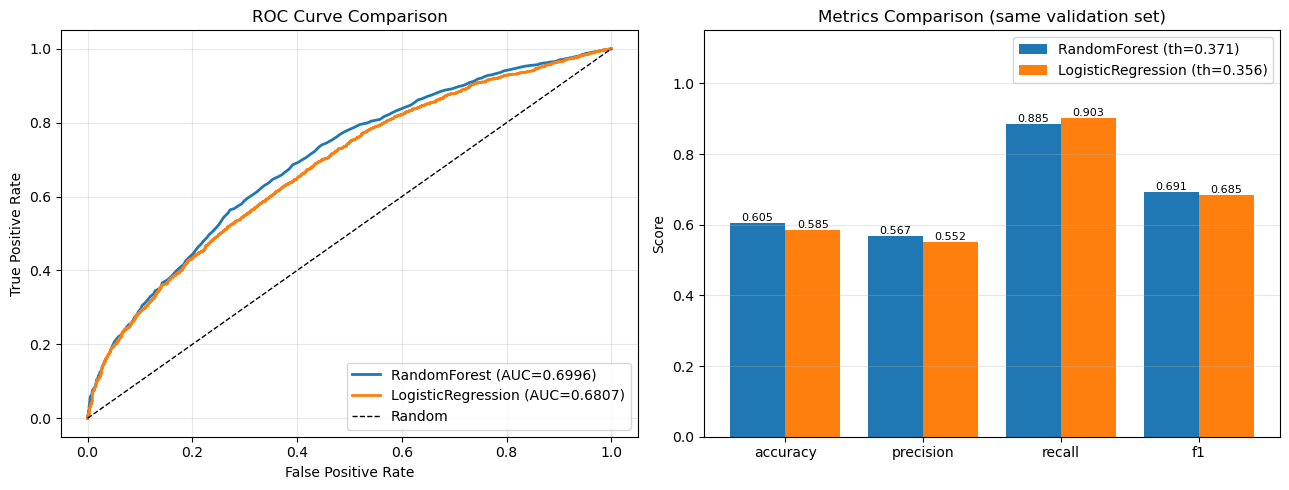

In [52]:
# ROC 疊圖 + 指標長條圖（以各自最佳門檻）
_ = q1.plot_model_comparison(y_val, prob_dict, {name_a: th_a, name_b: th_b})

## 11-3 錯誤型態分析：哪一類錯誤較多？

--- 門檻 0.5 ---


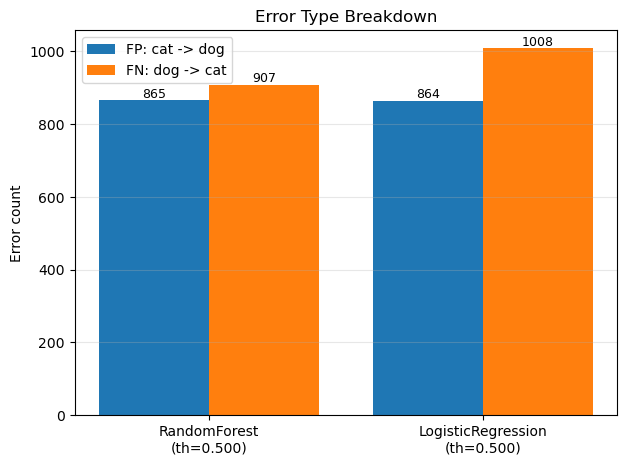

RandomForest         FP= 865, FN= 907 -> 較多的錯誤是 FN (把 dog 判成 cat)
LogisticRegression   FP= 864, FN=1008 -> 較多的錯誤是 FN (把 dog 判成 cat)

--- 各自最佳門檻 ---


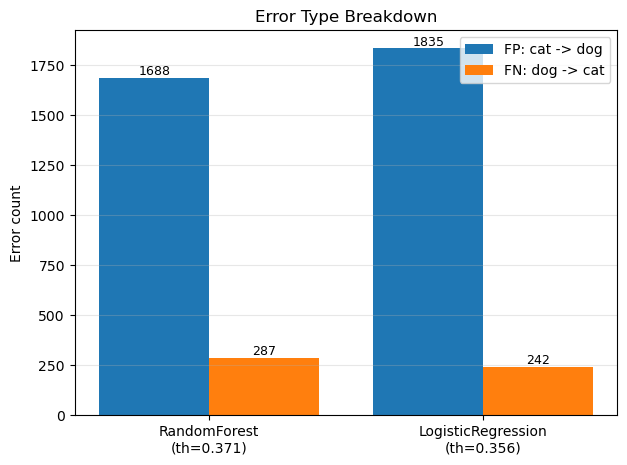

RandomForest         FP=1688, FN= 287 -> 較多的錯誤是 FP (把 cat 判成 dog)
LogisticRegression   FP=1835, FN= 242 -> 較多的錯誤是 FP (把 cat 判成 dog)


In [53]:
# FP = cat 被判成 dog（偽陽性）；FN = dog 被判成 cat（偽陰性）
print('--- 門檻 0.5 ---')
_ = q1.plot_error_breakdown(y_val, prob_dict, {name_a: 0.5, name_b: 0.5})

print('\n--- 各自最佳門檻 ---')
err_tuned = q1.plot_error_breakdown(y_val, prob_dict, {name_a: th_a, name_b: th_b})

In [54]:
# 依實際數字自動產生文字結論（重跑後仍然正確）
for nm in [name_a, name_b]:
    d = cmp_default.loc[nm]
    t = cmp_tuned.loc[nm]
    print(f'== {nm} ==')
    print(f'  th=0.500 : P={d["precision"]:.4f} R={d["recall"]:.4f} F1={d["f1"]:.4f} | '
          f'FP={int(d["FP(cat誤判成dog)"])} FN={int(d["FN(dog誤判成cat)"])} -> '
          f'{"Precision" if d["precision"] > d["recall"] else "Recall"} 較高')
    print(f'  th={t["threshold"]:.3f} : P={t["precision"]:.4f} R={t["recall"]:.4f} F1={t["f1"]:.4f} | '
          f'FP={int(t["FP(cat誤判成dog)"])} FN={int(t["FN(dog誤判成cat)"])} -> '
          f'{"Precision" if t["precision"] > t["recall"] else "Recall"} 較高')

win = cmp_tuned['f1'].idxmax()
print(f'\n以調校後 F1 判定，較佳模型為: {win} (F1={cmp_tuned.loc[win, "f1"]:.4f})')

== RandomForest ==
  th=0.500 : P=0.6481 R=0.6372 F1=0.6426 | FP=865 FN=907 -> Precision 較高
  th=0.371 : P=0.5673 R=0.8852 F1=0.6915 | FP=1688 FN=287 -> Recall 較高
== LogisticRegression ==
  th=0.500 : P=0.6333 R=0.5968 F1=0.6145 | FP=864 FN=1008 -> Precision 較高
  th=0.356 : P=0.5517 R=0.9032 F1=0.6850 | FP=1835 FN=242 -> Recall 較高

以調校後 F1 判定，較佳模型為: RandomForest (F1=0.6915)


# Quiz 2

In [ ]:

# 1. 下載資料集到本地快取
cache_path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Kaggle 快取路徑:", cache_path)

# 2. 定義目標資料夾路徑
target_dir = "data"
os.makedirs(target_dir, exist_ok=True)

# 3. 將快取內的資料夾與檔案同步至 data/
for item in os.listdir(cache_path):
    src = os.path.join(cache_path, item)
    dst = os.path.join(target_dir, item)
    if os.path.isdir(src):
        # dirs_exist_ok=True 確保目標資料夾存在時也能覆蓋/更新內容
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

print("同步完成！目前 data 資料夾內容:", os.listdir(target_dir))

100%|██████████| 0.98M/0.98M [00:00<00:00, 1.34MB/s]

Extracting model files...
Kaggle 快取路徑: C:\Users\Alan\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1
同步完成！目前 data 資料夾內容: ['confusion_matrix1.png', 'confusion_matrix2.png', 'Datasets', 'error_type1.png', 'error_type2.png', 'evaluation_curves1.png', 'evaluation_curves2.png', 'model_comparison.png', 'test_confusion_matrix.png', 'test_curves.png', 'threshold_curves1.png', 'threshold_curves2.png', 'UCI_Credit_Card.csv']
資料路徑: c:\Users\Alan\python\MMIP\week2\data\Datasets | 存在: True


## Q2-1 載入模組與資料

In [4]:
# 存檔後自動重載 Code/*.py，不必每次手動 reload
%load_ext autoreload
%autoreload 2

import os
import sys
from importlib import reload

import numpy as np
import pandas as pd
import torch

BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import Code.quiz2 as q2
reload(q2)

CSV_PATH = os.path.join(BASE_DIR, 'data', 'UCI_Credit_Card.csv')
RANDOM_STATE = 42
q2.set_seed(RANDOM_STATE)                    # 固定亂數種子
print('PyTorch:', torch.__version__, '| CUDA 可用:', torch.cuda.is_available())

df_cc = q2.load_data(CSV_PATH)
display(df_cc.head())

PyTorch: 1.7.1 | CUDA 可用: True
資料筆數: 30000, 欄位數: 25
缺失值總數: 0
標籤分布: 0(正常)=23364, 1(違約)=6636 (違約率 22.12%)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Q2-2 前處理：清理類別欄 + one-hot

In [5]:
# ID 移除；EDUCATION 0/5/6 與 MARRIAGE 0 併入「其他」；三個類別欄做 one-hot
X_cc, y_cc, feat_names_cc = q2.preprocess(df_cc)
print('特徵欄位:', feat_names_cc)

前處理後特徵矩陣: (30000, 29)（one-hot 後共 29 個特徵） | 金額欄已做 log 壓縮
特徵欄位: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_1', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


## Q2-3 資料切分（7:2:1，stratify 固定）

In [6]:
X_tr_cc, X_va_cc, X_te_cc, y_tr_cc, y_va_cc, y_te_cc = q2.split_data(
    X_cc, y_cc, random_state=RANDOM_STATE)

Train:  21000 筆 (70.0%) | 違約率 22.12%
Val  :   6000 筆 (20.0%) | 違約率 22.12%
Test :   3000 筆 (10.0%) | 違約率 22.13%


## Q2-4 Feature Scaling

`LIMIT_BAL`、`BILL_AMT*` 動輒數十萬，`AGE` 只有兩位數，尺度差距上萬倍。
不縮放時大數值欄位會主導梯度，MLP 幾乎無法收斂。
用 `StandardScaler` 轉成 mean≈0、std≈1，且**只在 70% 訓練集 fit**，驗證/測試集只 transform。

In [7]:
X_tr_s_cc, X_va_s_cc, X_te_s_cc, scaler_cc = q2.scale_features(X_tr_cc, X_va_cc, X_te_cc)

# 對照幾個欄位縮放前後的尺度
cmp_scale = pd.DataFrame({
    'feature': feat_names_cc[:6],
    'raw_mean': X_tr_cc[:, :6].mean(axis=0).round(1),
    'raw_std': X_tr_cc[:, :6].std(axis=0).round(1),
    'scaled_mean': X_tr_s_cc[:, :6].mean(axis=0).round(4),
    'scaled_std': X_tr_s_cc[:, :6].std(axis=0).round(4),
})
display(cmp_scale)

縮放前 訓練集各欄位數值範圍: min=-12.7, max=75.0
縮放後 訓練集各欄位數值範圍: min=-5.90, max=8.88 | mean=-0.0000, std=1.0000


,feature,raw_mean,raw_std,scaled_mean,scaled_std
0,LIMIT_BAL,11.7,0.9,-0.0,1.0000
1,AGE,35.5,9.2,-0.0,1.0000
2,PAY_0,-0.0,1.1,-0.0,1.0000
3,PAY_2,-0.1,1.2,0.0,1.0001
4,PAY_3,-0.2,1.2,0.0,1.0000
5,PAY_4,-0.2,1.2,-0.0,1.0000


## Q2-5 Stratified 5-Fold 交叉驗證（僅用訓練集）

In [8]:
# 每折重新建模、重新 fit scaler，確認架構與超參數穩定（約需 1~2 分鐘）
cv_table_cc = q2.cross_validate_mlp(
    X_tr_cc, y_tr_cc,
    n_splits=5, hidden_dims=(128, 64, 32), dropout=0.3, use_batchnorm=False,
    epochs=100, batch_size=128, lr=3e-4,
    optimizer_name='adam', scheduler_name='cosine',
    random_state=RANDOM_STATE,
)
display(cv_table_cc.round(4))

Fold 1/5: Acc=0.8188 P=0.6484 R=0.3950 F1=0.4910 AUC=0.7742 (best epoch 38)
Fold 2/5: Acc=0.8264 P=0.6805 R=0.4058 F1=0.5084 AUC=0.7811 (best epoch 64)
Fold 3/5: Acc=0.8186 P=0.6515 R=0.3864 F1=0.4851 AUC=0.7742 (best epoch 57)
Fold 4/5: Acc=0.8198 P=0.6654 R=0.3724 F1=0.4776 AUC=0.7741 (best epoch 31)
Fold 5/5: Acc=0.8231 P=0.6883 R=0.3660 F1=0.4779 AUC=0.7646 (best epoch 47)

5-Fold 平均:
  accuracy   0.8213 ± 0.0034
  precision  0.6668 ± 0.0175
  recall     0.3851 ± 0.0162
  f1         0.4880 ± 0.0127
  auc        0.7737 ± 0.0059


,accuracy,precision,recall,f1,auc,best_epoch
fold,,,,,,
1,0.8188,0.6484,0.3950,0.4910,0.7742,38
2,0.8264,0.6805,0.4058,0.5084,0.7811,64
3,0.8186,0.6515,0.3864,0.4851,0.7742,57
4,0.8198,0.6654,0.3724,0.4776,0.7741,31
5,0.8231,0.6883,0.3660,0.4779,0.7646,47


## Q2-6 基準模型 Baseline（不使用任何調校技巧）

刻意關掉全部六項技巧，當作改良前的對照組：

| 技巧 | Baseline | 對應參數 |
|---|---|---|
| Early Stopping | ✘ 不用 | `patience=None`、`restore_best=False`（跑滿 100 epochs，用最後一個 epoch 的權重）|
| Dropout | ✘ 不用 | `dropout=0.0` |
| L2 Regularization | ✘ 不用 | `weight_decay=0.0` |
| 調整 Learning Rate | ✘ 不調 | `lr=1e-3`（Adam 預設值）、`scheduler_name='none'` |
| 更換 Optimizer | ✘ 不換 | `optimizer_name='adam'` |
| 調整 Hidden Layer / Neuron | ✘ 不調 | `hidden_dims=(64,)`，單一隱藏層 |

其餘條件（資料切分、Feature Scaling、Batch Size、Epochs、亂數種子）與改良模型完全相同，確保差異只來自這六項。

In [9]:
# --- 基準模型的超參數：全部用最陽春的預設值 ---
BASE_HIDDEN_DIMS = (64,)      # 單一隱藏層，未調整
BASE_DROPOUT = 0.0            # 不用 Dropout
BASE_EPOCHS = 100             # 與改良模型相同，確保比較公平
BASE_BATCH_SIZE = 128
BASE_LR = 1e-3                # Adam 預設學習率，未調整
BASE_WEIGHT_DECAY = 0.0       # 不用 L2 Regularization
BASE_OPTIMIZER = 'adam'       # 未更換 Optimizer

model_base_cc = q2.build_model(
    input_dim=X_tr_s_cc.shape[1],
    hidden_dims=BASE_HIDDEN_DIMS,
    dropout=BASE_DROPOUT,
    use_batchnorm=False,
    seed=RANDOM_STATE,
)

model_base_cc, history_base_cc = q2.train_model(
    model_base_cc, X_tr_s_cc, y_tr_cc, X_va_s_cc, y_va_cc,
    X_test=X_te_s_cc, y_test=y_te_cc,   # 只為了畫 Test Loss 曲線，不參與任何訓練決策
    epochs=BASE_EPOCHS, batch_size=BASE_BATCH_SIZE,
    lr=BASE_LR, weight_decay=BASE_WEIGHT_DECAY,
    optimizer_name=BASE_OPTIMIZER,
    scheduler_name='none',    # 不做學習率調整
    patience=None,            # 不做 Early Stopping
    restore_best=False,       # 不挑最佳權重，直接用最後一個 epoch
    seed=RANDOM_STATE, log_every=10,
)

MLP(
  (net): Sequential(
    (0): Linear(in_features=29, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
可訓練參數量: 1,985
Epoch   1/100 | train_loss=0.4960 | clean_train=0.4505 | val_loss=0.4573 | test_loss=0.4532 | val_auc=0.7519 | lr=1.00e-03
Epoch  10/100 | train_loss=0.4310 | clean_train=0.4285 | val_loss=0.4393 | test_loss=0.4369 | val_auc=0.7731 | lr=1.00e-03
Epoch  20/100 | train_loss=0.4239 | clean_train=0.4211 | val_loss=0.4362 | test_loss=0.4353 | val_auc=0.7770 | lr=1.00e-03
Epoch  30/100 | train_loss=0.4197 | clean_train=0.4167 | val_loss=0.4358 | test_loss=0.4359 | val_auc=0.7761 | lr=1.00e-03
Epoch  40/100 | train_loss=0.4157 | clean_train=0.4134 | val_loss=0.4368 | test_loss=0.4370 | val_auc=0.7771 | lr=1.00e-03
Epoch  50/100 | train_loss=0.4131 | clean_train=0.4109 | val_loss=0.4379 | test_loss=0.4373 | val_auc=0.7737 | lr=1.00e-03
Epoch  60/100 | train_loss=0.4104 | clean_

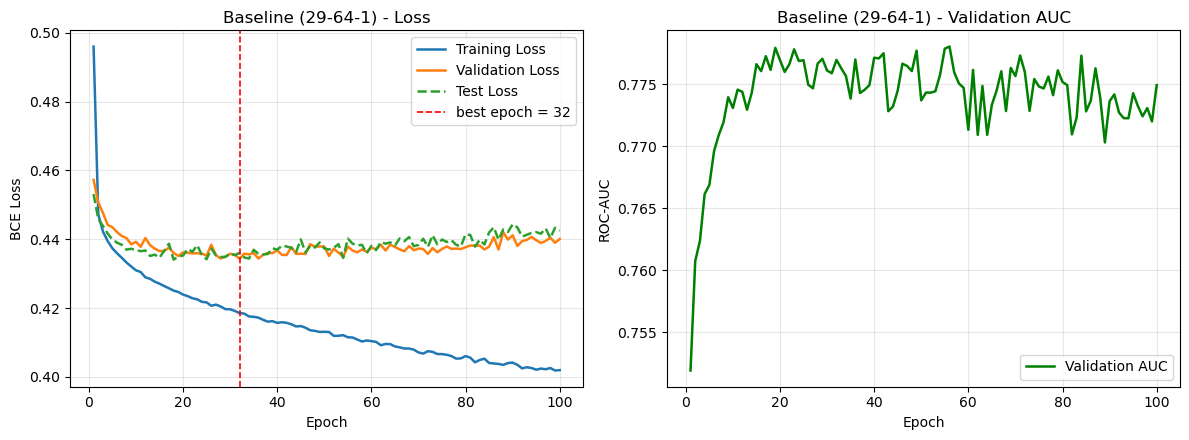

最後一個 epoch: train_loss=0.4020, val_loss=0.4401 (差距 +0.0381)
最低 val_loss=0.4344 @ epoch 32（沒有 early stopping，仍跑滿 100 epochs 且採用最後一個 epoch 的權重）


In [10]:
q2.plot_loss_curves(history_base_cc, title='Baseline (29-64-1)')

gap = history_base_cc['val_loss'][-1] - history_base_cc['train_loss'][-1]
print(f'最後一個 epoch: train_loss={history_base_cc["train_loss"][-1]:.4f}, '
      f'val_loss={history_base_cc["val_loss"][-1]:.4f} (差距 {gap:+.4f})')
print(f'最低 val_loss={history_base_cc["best_val_loss"]:.4f} @ epoch '
      f'{history_base_cc["best_epoch"]}（沒有 early stopping，仍跑滿 {BASE_EPOCHS} epochs '
      f'且採用最後一個 epoch 的權重）')

## Q2-7 改良模型：設定超參數

架構：`29 → 128 → 64 → 32 → 1`，每層 Linear 後接 ReLU + Dropout(0.3)，
輸出 1 個 logit 搭配 `BCEWithLogitsLoss`（數值上比 Sigmoid + BCE 穩定）。

**這裡不用 BatchNorm**：加了之後模型在 1~2 個 epoch 內就會衝到最低點，
loss 曲線看不到任何下降過程；改用較小的學習率（3e-4）＋ Cosine 學習率衰減，
讓 loss 在 60~80 個 epoch 之間平順收斂。

In [11]:
HIDDEN_DIMS = (128, 64, 32)   # 隱藏層神經元數
DROPOUT = 0.3                 # 每層丟棄 30% 神經元
USE_BATCHNORM = False         # 關閉 BatchNorm，避免一兩個 epoch 就收斂完
EPOCHS = 100                  # 需求 >= 50
BATCH_SIZE = 128
LEARNING_RATE = 3e-4
OPTIMIZER = 'adam'
SCHEDULER = 'cosine'          # 學習率餘弦衰減
PATIENCE = 20                 # 連續 20 個 epoch 沒進步就 early stopping

## Q2-8 建立改良模型並訓練

> **注意**：模型在同一個 cell 內重新建立，因此重複執行這個 cell 一定是從頭訓練。
> 若只重跑訓練而沿用已訓練好的 `model_cc`，等於接著訓練一個已收斂的模型，
> loss 會從最低點附近起跳，best epoch 就會出現在第 1~2 個 epoch。

In [12]:
# 每次執行都重新建模，確保訓練是從隨機初始權重開始
model_cc = q2.build_model(
    input_dim=X_tr_s_cc.shape[1],
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    use_batchnorm=USE_BATCHNORM,
    seed=RANDOM_STATE,
)

model_cc, history_cc = q2.train_model(
    model_cc, X_tr_s_cc, y_tr_cc, X_va_s_cc, y_va_cc,
    X_test=X_te_s_cc, y_test=y_te_cc,   # 只為了畫 Test Loss 曲線，不參與任何訓練決策
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE, weight_decay=1e-4,
    optimizer_name=OPTIMIZER, scheduler_name=SCHEDULER, patience=PATIENCE,
    seed=RANDOM_STATE, log_every=10,
)

MLP(
  (net): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)
可訓練參數量: 14,209
Epoch   1/100 | train_loss=0.5642 | clean_train=0.4670 | val_loss=0.4680 | test_loss=0.4696 | val_auc=0.7406 | lr=3.00e-04
Epoch  10/100 | train_loss=0.4442 | clean_train=0.4310 | val_loss=0.4373 | test_loss=0.4360 | val_auc=0.7711 | lr=2.94e-04
Epoch  20/100 | train_loss=0.4372 | clean_train=0.4249 | val_loss=0.4327 | test_loss=0.4312 | val_auc=0.7772 | lr=2.74e-04
Epoch  30/100 | train_loss=0.4315 | clean_train=0.4215 | val_loss=0.4309 | test_loss=0.4301 | val_auc=0.7800 | lr=2.42e-04
Epoch  40/100 | train_loss=0.4298 | clean_train=0.4191 

## Q2-9 Training Loss / Validation Loss 比較


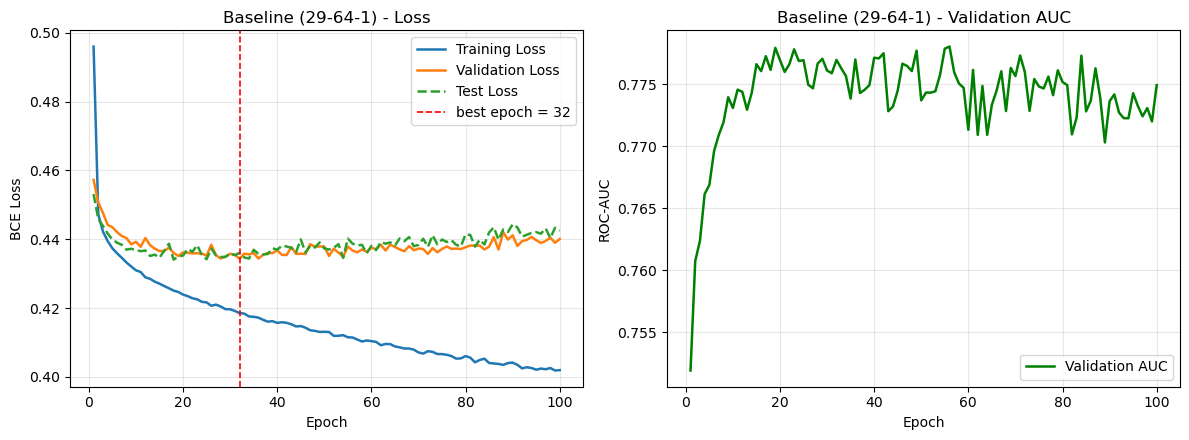

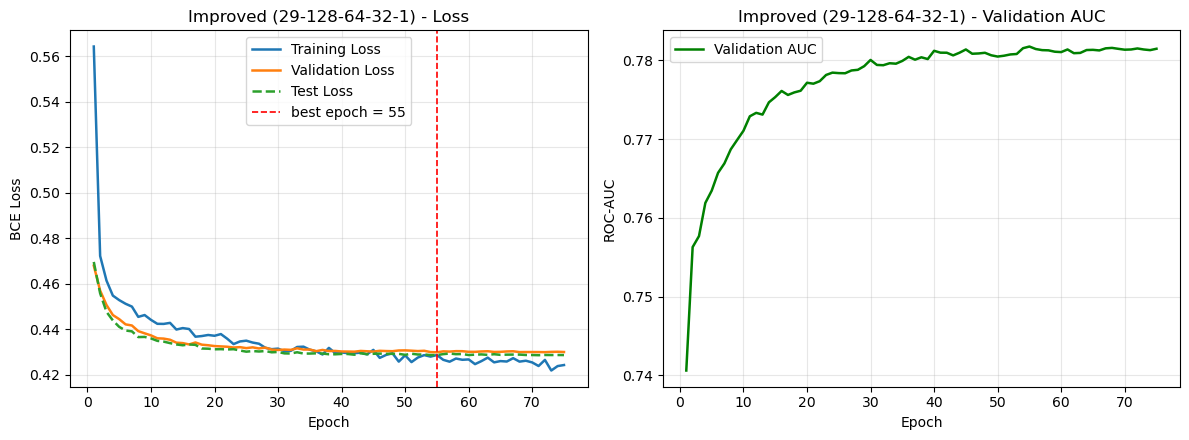

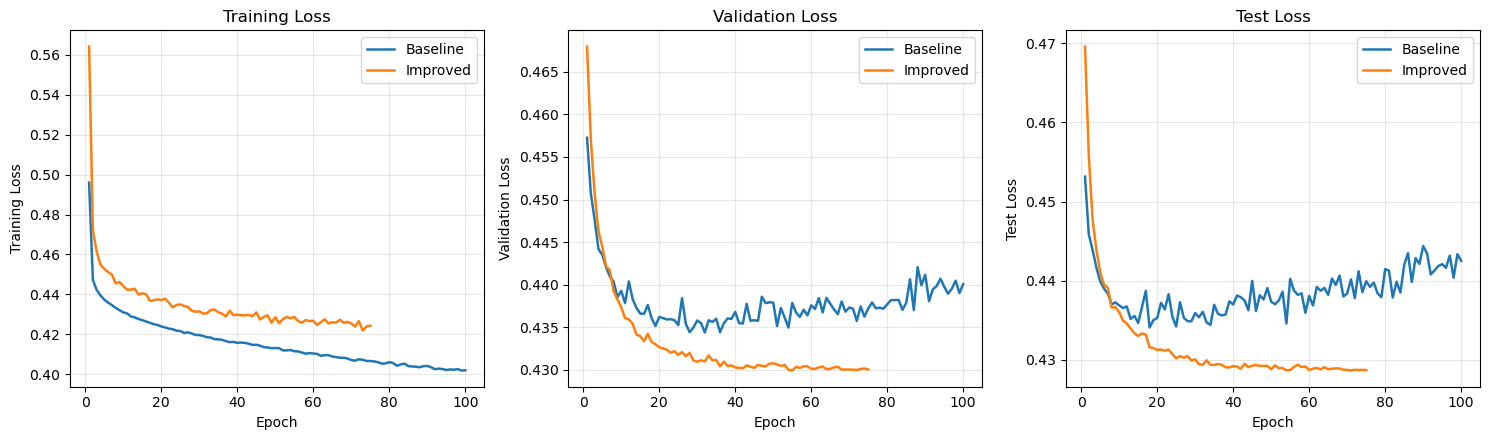

Baseline                 epochs=100 | 最低 val_loss=0.4344 @ epoch  32 | 最後 train=0.4020 / val=0.4401 | 過擬合差距=+0.0381
Improved                 epochs= 75 | 最低 val_loss=0.4299 @ epoch  55 | 最後 train=0.4243 / val=0.4300 | 過擬合差距=+0.0057
Baseline   最後 epoch: train=0.4020, val=0.4401, test=0.4425
Improved   最後 epoch: train=0.4243, val=0.4300, test=0.4287


In [13]:
# 每個模型一張圖：Training / Validation / Test Loss 畫在同一張
q2.plot_loss_curves(history_base_cc, title='Baseline (29-64-1)')
q2.plot_loss_curves(history_cc, title='Improved (29-128-64-32-1)')

# 兩模型疊圖比較：Training Loss / Validation Loss / Test Loss
q2.plot_history_comparison({'Baseline': history_base_cc, 'Improved': history_cc})

for nm, h in [('Baseline', history_base_cc), ('Improved', history_cc)]:
    print(f'{nm:<10s} 最後 epoch: train={h["train_loss"][-1]:.4f}, '
          f'val={h["val_loss"][-1]:.4f}, test={h["test_loss"][-1]:.4f}')


## Q2-10 Validation / Test 評估

[Improved / Validation] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=正常, 1=違約):
              pred_0    pred_1
  true_0        4423       250
  true_1         837       490
  Accuracy : 0.8188
  Precision: 0.6622
  Recall   : 0.3693
  F1-Score : 0.4741
  ROC-AUC  : 0.7818

[Improved / Test] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=正常, 1=違約):
              pred_0    pred_1
  true_0        2231       105
  true_1         432       232
  Accuracy : 0.8210
  Precision: 0.6884
  Recall   : 0.3494
  F1-Score : 0.4635
  ROC-AUC  : 0.7779

[Baseline / Validation] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=正常, 1=違約):
              pred_0    pred_1
  true_0        4388       285
  true_1         824       503
  Accuracy : 0.8152
  Precision: 0.6383
  Recall   : 0.3791
  F1-Score : 0.4757
  ROC-AUC  : 0.7749

[Baseline / Test] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=正常, 1=違約):
              pred_0    pred_1
  true_0        2216       120
  true_1

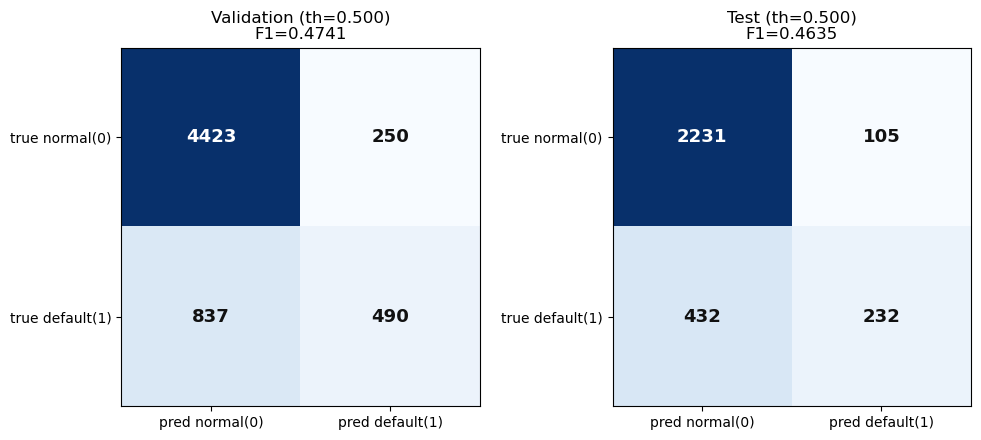

In [14]:
# 改良模型
val_probs_cc = q2.predict_proba(model_cc, X_va_s_cc)
test_probs_cc = q2.predict_proba(model_cc, X_te_s_cc)
m_val_cc = q2.evaluate(y_va_cc, val_probs_cc, 0.5, title='Improved / Validation')
m_test_cc = q2.evaluate(y_te_cc, test_probs_cc, 0.5, title='Improved / Test')

# 基準模型（同一份 Validation / Test）
val_probs_base_cc = q2.predict_proba(model_base_cc, X_va_s_cc)
test_probs_base_cc = q2.predict_proba(model_base_cc, X_te_s_cc)
m_val_base_cc = q2.evaluate(y_va_cc, val_probs_base_cc, 0.5, title='Baseline / Validation')
m_test_base_cc = q2.evaluate(y_te_cc, test_probs_base_cc, 0.5, title='Baseline / Test')

q2.plot_confusion_pair(m_val_cc, m_test_cc)

最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.2700 | best f1 = 0.5505
  該門檻下 Acc=0.7833, P=0.5086, R=0.5998



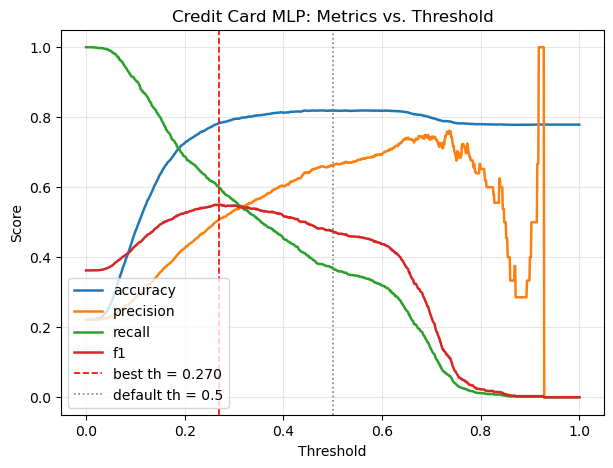

[Validation / Tuned] Threshold = 0.2700
Confusion Matrix (row=真實, col=預測, 0=正常, 1=違約):
              pred_0    pred_1
  true_0        3904       769
  true_1         531       796
  Accuracy : 0.7833
  Precision: 0.5086
  Recall   : 0.5998
  F1-Score : 0.5505
  ROC-AUC  : 0.7818

[Test / Tuned] Threshold = 0.2700
Confusion Matrix (row=真實, col=預測, 0=正常, 1=違約):
              pred_0    pred_1
  true_0        1980       356
  true_1         284       380
  Accuracy : 0.7867
  Precision: 0.5163
  Recall   : 0.5723
  F1-Score : 0.5429
  ROC-AUC  : 0.7779



In [15]:
# 違約樣本只佔 22%，門檻 0.5 的 Recall 偏低；沿用 Quiz1 的門檻搜尋工具調校
import Code.quiz1 as q1
reload(q1)

best_th_cc, best_f1_cc, th_tab_cc = q1.find_best_threshold(y_va_cc, val_probs_cc, metric='f1')
q1.plot_threshold_curves(th_tab_cc, best_th_cc, title='Credit Card MLP: Metrics vs. Threshold')

m_val_tuned_cc = q2.evaluate(y_va_cc, val_probs_cc, best_th_cc, title='Validation / Tuned')
m_test_tuned_cc = q2.evaluate(y_te_cc, test_probs_cc, best_th_cc, title='Test / Tuned')

# Quiz 3：Validation Dataset 的 Prediction Score 與 ROC / AUC

沿用 Quiz2 的**改良模型** `model_cc`（29-128-64-32-1），不重新訓練。
內容：對整個 Validation Dataset 輸出 Prediction Score / Probability → 畫 ROC Curve（X 軸 FPR、Y 軸 TPR）並標示 AUC
→ 再訓練一個 **XGBoost** 當第二個模型，兩條 ROC 疊在同一張圖比較。

> 變數皆以 `_q3` 結尾，與 Quiz1 / Quiz2 的變數互不影響。

## Q3-1 載入模組

In [28]:
import Code.quiz3 as q3
reload(q3)

# 門檻沿用 Q2-11 搜尋出來的最佳值；還沒跑過就退回 0.5
TH_Q3 = best_th_cc if 'best_th_cc' in globals() else 0.5
print('改良模型:', model_cc.__class__.__name__, '| Validation 筆數:', len(y_va_cc), '| 門檻:', round(float(TH_Q3), 4))

改良模型: MLP | Validation 筆數: 6000 | 門檻: 0.27


## Q3-2 Validation Dataset 的 Prediction Score / Probability

`predict_validation_scores` 一次對整個 validation set 做 forward，回傳每一筆的違約機率（Prediction Score）、
以門檻判定的預測類別、真實標籤與對錯，並附上幾欄原始特徵方便對照。

In [29]:
val_scores_q3 = q3.predict_validation_scores(
    model_cc, X_va_s_cc, y_va_cc,
    threshold=TH_Q3,
    feature_names=feat_names_cc,
    X_raw=X_va_cc,          # 未縮放的特徵，只為了表格好讀
    show=10,
)
display(val_scores_q3.head(20))

=== [MLP] Validation Dataset Prediction Score（共 6000 筆，門檻 0.2700）===
Score 範圍: min=0.0037, max=0.9283, mean=0.2250, median=0.1489
預測為違約(1): 1565 筆 (26.08%) | 真實違約(1): 1327 筆 (22.12%)
預測正確: 4700 / 6000 (78.33%)
平均 Score（依真實標籤分組）: 正常(0)=0.1766, 違約(1)=0.3953
ROC-AUC: 0.7818

前 10 筆明細:
 index   prob  pred  true  correct  LIMIT_BAL     AGE   PAY_0   PAY_2
     0 0.0425     0     0     True    11.9184 26.0000  0.0000  0.0000
     1 0.1382     0     0     True    12.9480 45.0000  1.0000 -1.0000
     2 0.0815     0     0     True    12.2061 37.0000 -2.0000 -2.0000
     3 0.1269     0     0     True    11.9184 35.0000 -1.0000 -1.0000
     4 0.6126     1     1     True    11.1563 30.0000  2.0000  2.0000
     5 0.4274     1     0    False     9.9035 43.0000  1.0000 -1.0000
     6 0.3359     1     0    False    12.9715 34.0000  1.0000  2.0000
     7 0.1498     0     0     True    10.5967 49.0000  0.0000  0.0000
     8 0.6868     1     0    False    10.8198 24.0000  2.0000  0.0000
     9 0.0524    

,index,prob,pred,true,correct,LIMIT_BAL,AGE,PAY_0,PAY_2
0,0,0.042485,0,0,True,11.918397,26.0,0.0,0.0
1,1,0.138199,0,0,True,12.948012,45.0,1.0,-1.0
2,2,0.081451,0,0,True,12.206078,37.0,-2.0,-2.0
3,3,0.126881,0,0,True,11.918397,35.0,-1.0,-1.0
4,4,0.612612,1,1,True,11.156265,30.0,2.0,2.0
5,5,0.427383,1,0,False,9.903538,43.0,1.0,-1.0
6,6,0.335879,1,0,False,12.971542,34.0,1.0,2.0
7,7,0.149769,0,0,True,10.596660,49.0,0.0,0.0
8,8,0.686771,1,0,False,10.819798,24.0,2.0,0.0
9,9,0.052396,0,0,True,12.793862,30.0,-1.0,-1.0


Prediction Score 分布（區間平均分數 vs. 實際違約率）:
                  n  mean_score  actual_rate
prob                                        
(-0.001, 0.1]  1766      0.0691       0.0702
(0.1, 0.2]     2094      0.1435       0.1385
(0.2, 0.3]      743      0.2444       0.2261
(0.3, 0.4]      398      0.3478       0.3593
(0.4, 0.5]      259      0.4414       0.4324
(0.5, 0.6]      129      0.5509       0.5116
(0.6, 0.7]      367      0.6544       0.6649
(0.7, 0.8]      221      0.7318       0.7466
(0.8, 0.9]       18      0.8462       0.7222
(0.9, 1.0]        5      0.9180       0.4000


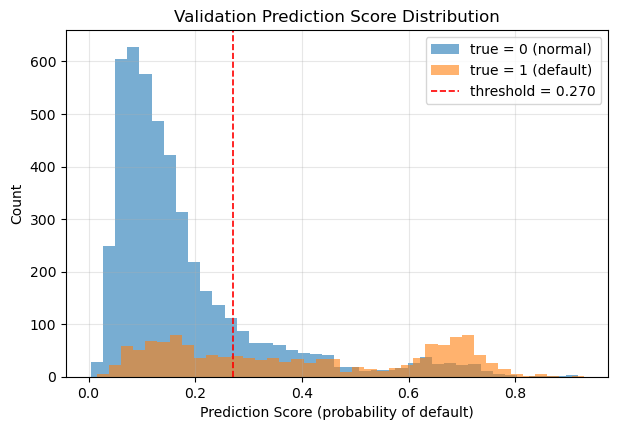

In [31]:
# Score 分布：等寬區間的平均分數 vs. 實際違約率（看校準程度），以及分色直方圖
_ = q3.score_summary_by_bin(val_scores_q3, bins=10)
q3.plot_score_distribution(val_scores_q3, threshold=TH_Q3)

## Q3-3 ROC Curve 與 AUC

X 軸 = False Positive Rate，Y 軸 = True Positive Rate，AUC 數值直接標示在圖上。
紅點是目前使用的門檻在曲線上的位置。

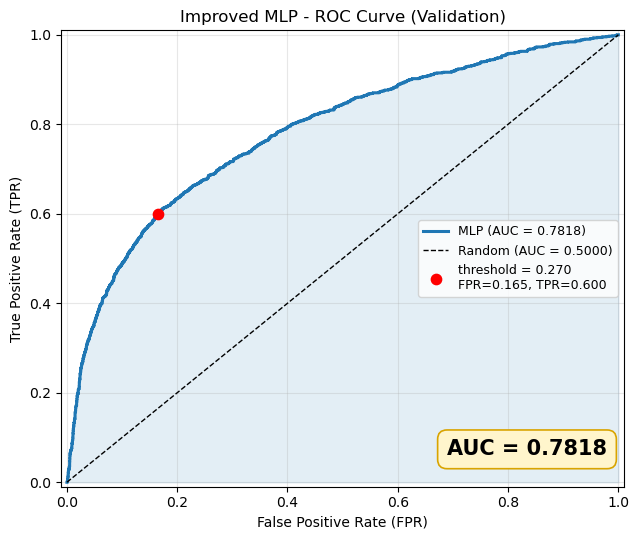

Improved MLP - ROC Curve (Validation): AUC = 0.7818


In [32]:
auc_q3, fpr_q3, tpr_q3, ths_q3 = q3.plot_roc_curve(
    y_va_cc, val_scores_q3['prob'].values,
    title='Improved MLP - ROC Curve (Validation)',
    mark_threshold=TH_Q3,
)

In [33]:
# 不同門檻沿著 ROC 曲線移動的對應點（AUC 與門檻無關，門檻只決定站在曲線哪一點）
_ = q3.roc_points(fpr_q3, tpr_q3, ths_q3, thresholds=(0.1, 0.2, TH_Q3, 0.4, 0.5))

ROC 曲線上的門檻對應點:
 threshold    FPR  TPR (Recall)
    0.1000 0.6512        0.9066
    0.2000 0.2613        0.6880
    0.2700 0.1646        0.5998
    0.4000 0.0850        0.4521
    0.5000 0.0535        0.3693


## Q3-4 第二個模型：XGBoost（小 learning rate + 早停）

用**與 Quiz2 完全相同**的 Training Dataset（`X_tr_s_cc` / `y_tr_cc`）與 Validation Dataset（`X_va_s_cc` / `y_va_cc`），
不重新切分、不重新縮放，這樣兩個模型的 ROC 才比得起來。

演算法選 **XGBoost**（Gradient Boosting Decision Tree）：先前也把 LogisticRegression / SVM (RBF) /
DecisionTree / RandomForest / NaiveBayes 一起疊圖比過，XGBoost 的 Validation AUC 最高，
所以這裡只留它當代表，跟改良版 MLP 一對一比較。

=== XGBoost (XGBClassifier) ===
訓練資料: 17850 筆 × 29 個特徵（早停集 3150 筆，從 Training Dataset 切出）
主要超參數: {'colsample_bytree': 0.8, 'early_stopping_rounds': 100, 'learning_rate': 0.02, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 2000, 'reg_lambda': 1.0, 'scale_pos_weight': 3.521276595744681, 'subsample': 0.8}
早停: 第 320 輪最佳（eval AUC = 0.7860），實際使用 321 / 2000 棵樹
訓練耗時: 0.7 秒 | Training AUC: 0.8180


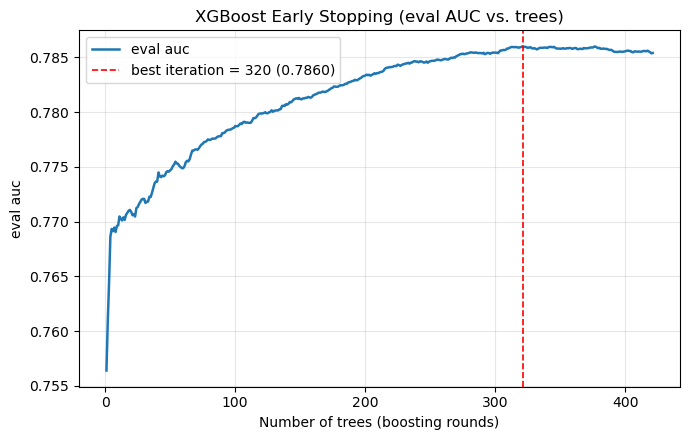

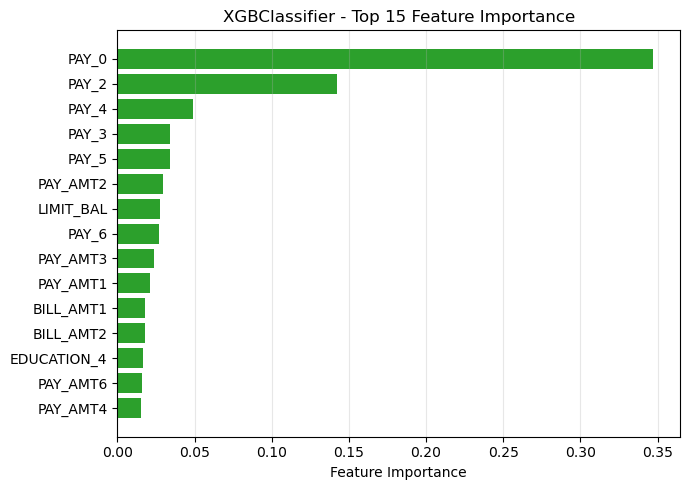

In [35]:
# 預設就是 lr=0.02 + 早停（early_stopping_rounds=100，早停集從 train 切 15%）
xgb_q3 = q3.train_xgboost(
    X_tr_s_cc, y_tr_cc,
    random_state=RANDOM_STATE,
    learning_rate=0.02,             # 想試別的值就改這裡
    n_estimators=2000,              # 早停開著，這只是上限
    early_stopping_rounds=100,      # 設成 None 就退回「跑滿 n_estimators、不早停」
)
XGB_NAME_Q3 = q3.XGB_DISPLAY_NAME   # 'XGBoost'

# 早停集 AUC 隨樹數的變化：紅線就是早停選中的那一輪（之後再加樹只是變差）
_ = q3.plot_xgb_learning_curve(xgb_q3)

# 哪些特徵對 XGBoost 最重要（預設看 gain 的相對比例）
imp_q3 = q3.feature_importance(xgb_q3, feat_names_cc, top_k=15)

## Q3-5 XGBoost 對 Validation Dataset 的 Prediction Score

`predict_xgb_scores` 走 `predict_proba(X)[:, 1]` 取違約機率，
輸出欄位與 Q3-2 的 MLP 版完全一致（`index / prob / pred / true / correct`）。

MLP (Improved)       best threshold = 0.2700 | F1 = 0.5505
XGBoost              best threshold = 0.5570 | F1 = 0.5531
=== Validation Dataset 模型比較（同一份資料、同一組特徵）===
                  AUC     AP  threshold  Accuracy  Precision  Recall     F1
model                                                                      
XGBoost        0.7837 0.5559     0.5570    0.7910     0.5247  0.5848 0.5531
MLP (Improved) 0.7818 0.5426     0.2700    0.7833     0.5086  0.5998 0.5505

AUC 最高: XGBoost (0.7837)


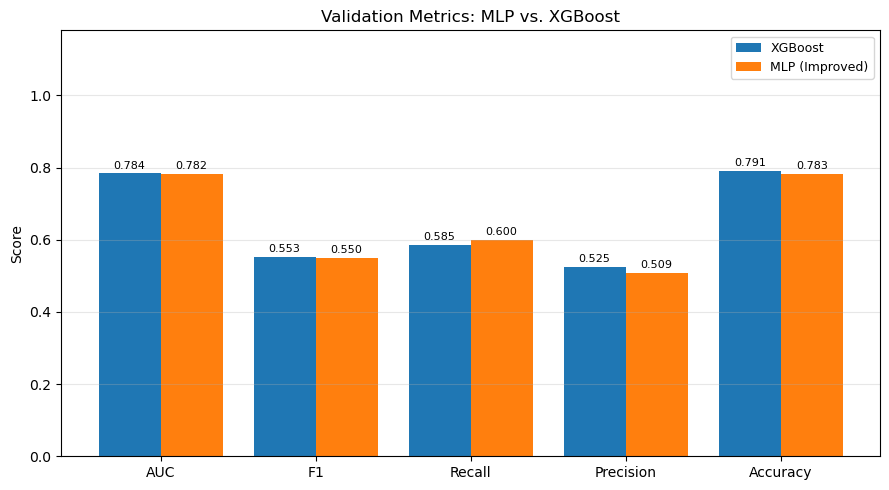

In [42]:
best_th_q3 = {}
for name_q3, p_q3 in probs_q3.items():
    th_q3, f1_q3, _ = q1.find_best_threshold(y_va_cc, p_q3, metric='f1', verbose=False)
    best_th_q3[name_q3] = th_q3
    print(f'{name_q3:<20s} best threshold = {th_q3:.4f} | F1 = {f1_q3:.4f}')

lb_q3 = q3.leaderboard(y_va_cc, probs_q3, thresholds=best_th_q3, sort_by='AUC')
q3.plot_leaderboard(lb_q3)

In [ ]:
xgb_scores_q3 = q3.predict_xgb_scores(
    xgb_q3, X_va_s_cc, y_va_cc,
    threshold= th_q3,
    feature_names=feat_names_cc,
    X_raw=X_va_cc,
    show=10,
)
display(xgb_scores_q3.head(20))

=== [XGBoost] Validation Dataset Prediction Score（共 6000 筆，門檻 0.5570）===
Score 範圍: min=0.0683, max=0.9510, mean=0.4281, median=0.3738
預測為違約(1): 1479 筆 (24.65%) | 真實違約(1): 1327 筆 (22.12%)
預測正確: 4746 / 6000 (79.10%)
平均 Score（依真實標籤分組）: 正常(0)=0.3744, 違約(1)=0.6170
ROC-AUC: 0.7837

前 10 筆明細:
 index   prob  pred  true  correct  LIMIT_BAL     AGE   PAY_0   PAY_2
     0 0.1584     0     0     True    11.9184 26.0000  0.0000  0.0000
     1 0.3850     0     0     True    12.9480 45.0000  1.0000 -1.0000
     2 0.2030     0     0     True    12.2061 37.0000 -2.0000 -2.0000
     3 0.3821     0     0     True    11.9184 35.0000 -1.0000 -1.0000
     4 0.8574     1     1     True    11.1563 30.0000  2.0000  2.0000
     5 0.7074     1     0    False     9.9035 43.0000  1.0000 -1.0000
     6 0.4998     0     0     True    12.9715 34.0000  1.0000  2.0000
     7 0.4600     0     0     True    10.5967 49.0000  0.0000  0.0000
     8 0.8454     1     0    False    10.8198 24.0000  2.0000  0.0000
     9 0.0935

,index,prob,pred,true,correct,LIMIT_BAL,AGE,PAY_0,PAY_2
0,0,0.158419,0,0,True,11.918397,26.0,0.0,0.0
1,1,0.385022,0,0,True,12.948012,45.0,1.0,-1.0
2,2,0.203049,0,0,True,12.206078,37.0,-2.0,-2.0
3,3,0.382126,0,0,True,11.918397,35.0,-1.0,-1.0
4,4,0.857386,1,1,True,11.156265,30.0,2.0,2.0
5,5,0.707350,1,0,False,9.903538,43.0,1.0,-1.0
6,6,0.499777,0,0,True,12.971542,34.0,1.0,2.0
7,7,0.460026,0,0,True,10.596660,49.0,0.0,0.0
8,8,0.845390,1,0,False,10.819798,24.0,2.0,0.0
9,9,0.093510,0,0,True,12.793862,30.0,-1.0,-1.0


## Q3-6 兩模型 ROC Curve 疊圖 + 各自的 AUC

同一張圖：X 軸 FPR、Y 軸 TPR，兩條曲線分別是改良版 MLP 與 XGBoost，
各自的 AUC 同時寫在 legend 與圖中右下角的方框；曲線上的圓點是各自使用的門檻位置。

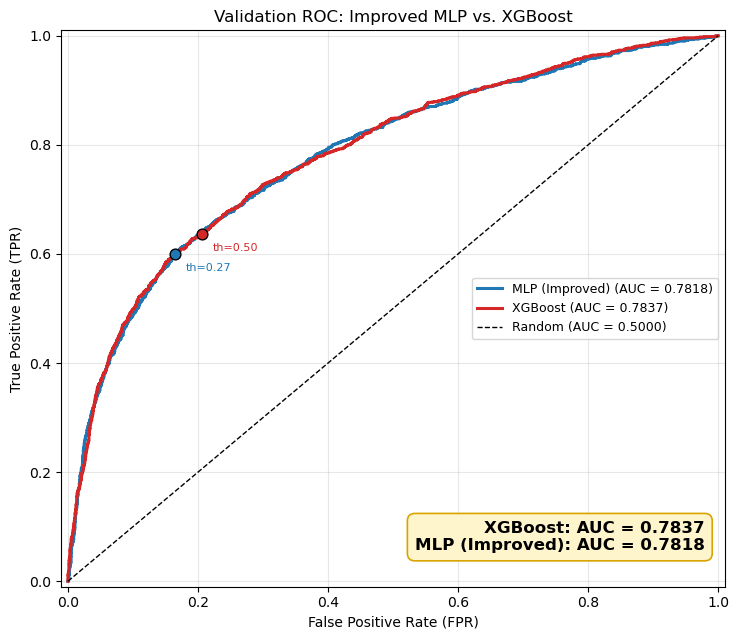

各模型 AUC（同一份 Validation Dataset）:
                  AUC
model                
MLP (Improved) 0.7818
XGBoost        0.7837
AUC 較高者: XGBoost (0.7837)


,AUC
model,
MLP (Improved),0.781750
XGBoost,0.783717


In [ ]:
# 之後的比較都用這個 dict（key 是模型名稱，value 是 validation 的 Prediction Score）
probs_q3 = {
    'MLP (Improved)': val_scores_q3['prob'].values,
    XGB_NAME_Q3: xgb_scores_q3['prob'].values,
}

auc_table_q3 = q3.plot_roc_comparison(
    y_va_cc, probs_q3,
    mark_thresholds={'MLP (Improved)': TH_Q3, XGB_NAME_Q3: th_q3},
    title='Validation ROC: Improved MLP vs. XGBoost',
)
display(auc_table_q3)

In [40]:
# 以 F1 排名（門檻各自調校後），看哪個模型整體表現較好
display(lb_q3.sort_values('F1', ascending=False).round(4))

,AUC,AP,threshold,Accuracy,Precision,Recall,F1
model,,,,,,,
XGBoost,0.7837,0.5559,0.557,0.7910,0.5247,0.5848,0.5531
MLP (Improved),0.7818,0.5426,0.270,0.7833,0.5086,0.5998,0.5505
